In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [4]:
%%time 

YEAR_START = 1958
YEAR_FIN = 1960

PATH_3hr = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_3hr_output/MONTHLY/"
PATH_6hr = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl/MONTHLY/"


PATH_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_3hr_output/cpl/hist/'
filename_raw = 'a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_3hr_output.cpl.hi.1959-01-01-00000.nc'

lat_raw = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['ocnExp_lat'].isel(time=0, drop = True).rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})

# area_raw = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['MED_ocn_area'].isel(time=0)
# R2 = 6371e3**2
# area = (area_raw*R2).rename({"MED_ocn_ny": "y", "MED_ocn_nx": "x"})


land_mask = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
# land_mask = land_mask.where(land_mask != 0, np.nan)


weights = np.cos(np.deg2rad(lat_raw))*land_mask
weights = weights / weights.sum()  # Normalize so they sum to 1
# weights.plot()
# weights.sum()


variables = {
    "latent": "ocnExp_Foxx_lat",
    "sensible": "ocnExp_Foxx_sen",
    "swnet": "ocnExp_Foxx_swnet",
    "lwnet": "ocnExp_Foxx_lwnet"
}

yearly_data_3hr = {}
yearly_data_6hr = {}

for var_type, var_name in variables.items():
    if var_type not in yearly_data_3hr:
        yearly_data_3hr[var_type] = []

    for YEAR in range(YEAR_START, YEAR_FIN+1):  
        model_file = f"{PATH_3hr}{YEAR}.{var_type}.monthly.nc"
        model_ds = xr.open_dataset(model_file)
        model_var = model_ds[var_name].fillna(0)
        # ice_land_mask = xr.where(model_var == 0, np.nan, 1)

        # weights = (land_mask * area)/(land_mask * area).sum(dim=("y", "x"))
        # weights = weights.fillna(0)

        weights = np.cos(np.deg2rad(lat_raw))*land_mask
        weights = weights / weights.sum()  # Normalize so they sum to 1
        weights_br = weights.broadcast_like(model_ds[var_name])

        var_time_series = model_var.weighted(weights_br).mean(dim=["x", "y"])

        yearly_data_3hr[var_type].append(var_time_series.mean('time').values)

        del weights_br, weights
        

for var_type, var_name in variables.items():
    if var_type not in yearly_data_6hr:
        yearly_data_6hr[var_type] = []

    for YEAR in range(YEAR_START, YEAR_FIN+1):  
        model_file = f"{PATH_6hr}{YEAR}.{var_type}.monthly.nc"
        model_ds = xr.open_dataset(model_file)
        model_var = model_ds[var_name].fillna(0)
        # ice_land_mask = xr.where(model_var == 0, np.nan, 1)

        # weights = (land_mask * area)/(land_mask * area).sum(dim=("y", "x"))
        # weights = weights.fillna(0)

        weights = np.cos(np.deg2rad(lat_raw))*land_mask
        weights = weights / weights.sum()  # Normalize so they sum to 1
        weights_br = weights.broadcast_like(model_ds[var_name])

        var_time_series = model_var.weighted(weights_br).mean(dim=["x", "y"])

        yearly_data_6hr[var_type].append(var_time_series.mean('time').values)

        del weights_br, weights

# year_range = np.arange(YEAR_START, YEAR_FIN + 1)

# yearly_ds = xr.Dataset(
#         {var_type: (["time"], yearly_data[var_type]) for var_type in variables.keys()},
#         coords={"time": year_range}
#     )

CPU times: user 1.25 s, sys: 294 ms, total: 1.55 s
Wall time: 6.38 s


Text(0.5, 1.0, 'swnet')

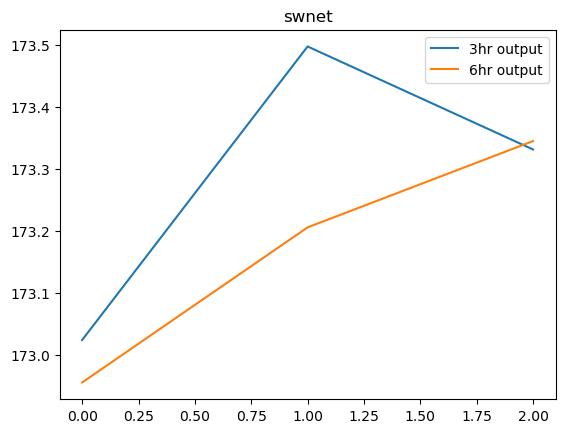

In [18]:
plt.plot(np.array(yearly_data_3hr['swnet']), label = '3hr output')
plt.plot(np.array(yearly_data_6hr['swnet']), label = '6hr output')
plt.legend()
plt.title('swnet')

Text(0.5, 1.0, 'lwnet')

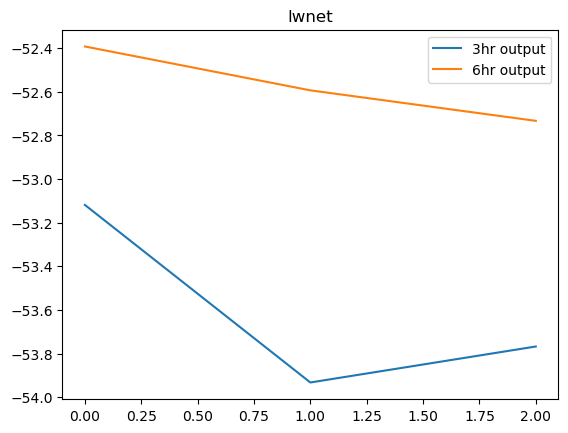

In [19]:
plt.plot(np.array(yearly_data_3hr['lwnet']), label = '3hr output')
plt.plot(np.array(yearly_data_6hr['lwnet']), label = '6hr output')
plt.legend()
plt.title('lwnet')

Text(0.5, 1.0, 'latent')

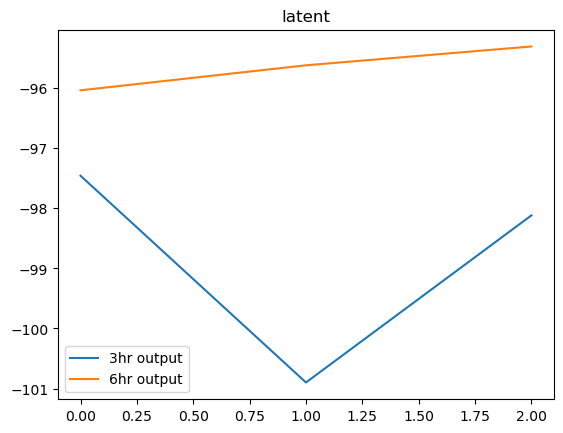

In [20]:
plt.plot(np.array(yearly_data_3hr['latent']), label = '3hr output')
plt.plot(np.array(yearly_data_6hr['latent']), label = '6hr output')
plt.legend()
plt.title('latent')

In [ ]:
plt.plot(np.array(yearly_data_3hr['latent']), label = '3hr output')
plt.plot(np.array(yearly_data_6hr['latent']), label = '6hr output')
plt.legend()
plt.title('latent')